In [ ]:
     #Cell 1 — Mount Drive, install packages, quick dataset check
# Cell 1 — Mount Google Drive, install libs, and inspect dataset
from pathlib import Path
from pprint import pprint

# Mount Drive (Colab will prompt)
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")
print("Dataset path:", DATASET_PATH)

# Install required packages
# deepface for embeddings/detectors, facenet-pytorch for MTCNN option, tqdm for progress



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/Face recognition/Extracted_subjects


In [ ]:
!pip install --quiet deepface==0.0.87 facenet-pytorch==2.5.2 tqdm scikit-learn matplotlib seaborn joblib

# Quick directory summary
if DATASET_PATH.exists():
    entries = sorted([p for p in DATASET_PATH.iterdir()])
    print(f"Found {len(entries)} items at dataset root.")
    for p in entries[:30]:
        print("-", p.name, "(dir)" if p.is_dir() else "(file)")
else:
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.6/93.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.5 MB/s eta 0:00:00
Found 7395 items at dataset root.
- subject100_subject100.0.png (file)
- subject100_subject100.1.png (file)
- subject100_subject100.10.png (file)
- subject100_subject100.11.png (file)
- subject100_subject100.12.png (file)
- subject100_subject100.13.png (file)
- subject100_subject100.14.png (file)
- subject100_subject100.15.png (file)
- subject100_subject100.16.png (file)
- subject100_subject100.17.png (file)
- subject100_subject100.18.png (file)
- subject100_subject100.19.png (file)
- subject100_subject100.2.png (file)
- sub

In [ ]:
#Cell 2 — Create processed folder & choose detector (MTCNN or RetinaFace)
# Cell 2 — Create processed output folder and set parameters
from pathlib import Path
DATASET_PATH = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")
PROCESSED_ROOT = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed")
ALIGNED_DIR = PROCESSED_ROOT / "aligned"
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

# Choose detector: options = "mtcnn" or "retinaface"
DETECTOR = "mtcnn"   # set "retinaface" to use DeepFace/retinaface backend

print("Processed dir:", ALIGNED_DIR)
print("Detector:", DETECTOR)


Processed dir: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned
Detector: mtcnn


In [ ]:
#Cell 3 — Face detection + alignment and save aligned crops
# Cell 3 — Detect and align faces, save crops into ALIGNED_DIR/<subject>/*.jpg
import os
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import numpy as np

DATASET_PATH = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")
ALIGNED_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

DETECTOR = "mtcnn"  # "mtcnn" or "retinaface"

if DETECTOR == "mtcnn":
    from facenet_pytorch import MTCNN
    mtcnn = MTCNN(keep_all=False, device='cuda' if __import__('torch').cuda.is_available() else 'cpu')
elif DETECTOR == "retinaface":
    from deepface.detectors import FaceDetector
    detector_backend = FaceDetector.build_model("retinaface")
else:
    raise ValueError("DETECTOR must be 'mtcnn' or 'retinaface'")

img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}

for subject in sorted([d for d in DATASET_PATH.iterdir() if d.is_dir()]):
    out_sub_dir = ALIGNED_DIR / subject.name
    out_sub_dir.mkdir(parents=True, exist_ok=True)
    imgs = [p for p in subject.rglob("*") if p.suffix.lower() in img_exts]
    for i, img_path in enumerate(tqdm(imgs, desc=f"Processing {subject.name}", leave=False)):
        try:
            img = Image.open(img_path).convert('RGB')
            if DETECTOR == "mtcnn":
                # mtcnn returns a PIL or tensor crop
                box_img = mtcnn(img)
                if box_img is None:
                    continue
                # box_img is a PIL Image when keep_all=False; convert to PIL and save
                if hasattr(box_img, "permute"):
                    # tensor -> PIL
                    arr = ((box_img.permute(1,2,0).numpy()*255).astype('uint8'))
                    crop = Image.fromarray(arr)
                else:
                    crop = box_img
            else:  # retinaface via deepface
                from deepface.commons import functions
                img_bgr = np.array(img)[:, :, ::-1]
                resp = FaceDetector.detect_faces(detector_backend, img_bgr, align=False)
                if resp is None or len(resp) == 0:
                    continue
                # resp is list of dicts with 'facial_area' key
                fa = resp[0]['facial_area']  # [x, y, w, h]
                x, y, w, h = map(int, fa)
                crop = img.crop((x, y, x + w, y + h))
            # Resize crop to standard size (112x112 for ArcFace-like)
            crop = crop.resize((112, 112))
            out_path = out_sub_dir / f"{img_path.stem}_crop.jpg"
            crop.save(out_path, quality=95)
        except Exception as e:
            # skip problematic images
            # print(f"skip {img_path} -> {e}")
            continue

print("Done. Aligned images saved under:", ALIGNED_DIR)



Done. Aligned images saved under: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned


In [ ]:
#Cell 4 — Count aligned images and show sample distribution
# Cell 4 — Summary of aligned dataset
from pathlib import Path
ALIGNED_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")
img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}

subject_counts = {}
total = 0
for sub in sorted([d for d in ALIGNED_DIR.iterdir() if d.is_dir()]):
    imgs = list(sub.glob("*"))
    c = sum(1 for f in imgs if f.suffix.lower() in img_exts)
    subject_counts[sub.name] = c
    total += c

print("Subjects (aligned):", len(subject_counts))
print("Total aligned images:", total)
# top 10
top10 = sorted(subject_counts.items(), key=lambda x: -x[1])[:10]
print("Top 10 subjects by count:", top10)


Subjects (aligned): 130
Total aligned images: 7215
Top 10 subjects by count: [('subject8', 85), ('subject121', 84), ('subject85', 75), ('subject97', 75), ('subject100', 65), ('subject16', 65), ('subject35', 65), ('subject50', 65), ('subject76', 65), ('subject84', 65)]


In [ ]:
# Cell A — Inspect aligned folder and dataset root
from pathlib import Path
from PIL import Image
import os

ALIGNED_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")
DATASET_PATH = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")

print("ALIGNED_DIR exists:", ALIGNED_DIR.exists())
if ALIGNED_DIR.exists():
    subdirs = sorted([d for d in ALIGNED_DIR.iterdir() if d.is_dir()])
    print("Number of subject dirs in ALIGNED_DIR:", len(subdirs))
    # show up to 10 subdirs and counts
    for d in subdirs[:10]:
        files = [p for p in d.glob("*") if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]
        print(f"  {d.name}: {len(files)} images (showing up to 5): {[p.name for p in files[:5]]}")
else:
    print("ALIGNED_DIR missing or not mounted.")

print("\nChecking original dataset root:")
if DATASET_PATH.exists():
    subs = sorted([d for d in DATASET_PATH.iterdir() if d.is_dir()])
    print("Number of subject dirs in DATASET_PATH:", len(subs))
    for d in subs[:10]:
        files = [p for p in d.glob("*") if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]
        print(f"  {d.name}: {len(files)} images (showing up to 5): {[p.name for p in files[:5]]}")
else:
    print("Original dataset path not found. Check Drive mount and path string.")


ALIGNED_DIR exists: True
Number of subject dirs in ALIGNED_DIR: 130
  subject1: 59 images (showing up to 5): ['subject1_subject1.33_aligned.jpg', 'subject1_subject1.25_aligned.jpg', 'subject1_subject1.49_aligned.jpg', 'subject1_subject1.6_aligned.jpg', 'subject1_subject1.27_aligned.jpg']
  subject10: 42 images (showing up to 5): ['subject10_subject10.10_aligned.jpg', 'subject10_subject10.33_aligned.jpg', 'subject10_subject10.5_aligned.jpg', 'subject10_subject10.2_aligned.jpg', 'subject10_subject10.43_aligned.jpg']
  subject100: 65 images (showing up to 5): ['subject100_subject100.62_aligned.jpg', 'subject100_subject100.5_aligned.jpg', 'subject100_subject100.13_aligned.jpg', 'subject100_subject100.14_aligned.jpg', 'subject100_subject100.36_aligned.jpg']
  subject101: 60 images (showing up to 5): ['subject101_subject101.34_aligned.jpg', 'subject101_subject101.12_aligned.jpg', 'subject101_subject101.53_aligned.jpg', 'subject101_subject101.41_aligned.jpg', 'subject101_subject101.49_aligned

In [ ]:
# Cell B (New Working Version)
# Detect and align faces using facenet-pytorch MTCNN and save crops.
# This replaces RetinaFace and avoids DeepFace detector issues.

!pip install --quiet facenet-pytorch

from facenet_pytorch import MTCNN
from pathlib import Path
from PIL import Image
import torch
import numpy as np
from tqdm import tqdm

DATASET_PATH = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")
ALIGNED_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mtcnn = MTCNN(image_size=112, margin=20, keep_all=False, device=device)

img_exts = {".jpg", ".jpeg", ".png", ".bmp"}

total = 0
saved = 0
failed = 0

subjects = sorted([d for d in DATASET_PATH.iterdir() if d.is_dir()])

print("Subjects found:", len(subjects))

for subject in subjects:
    out_dir = ALIGNED_DIR / subject.name
    out_dir.mkdir(parents=True, exist_ok=True)

    images = [p for p in subject.rglob("*") if p.suffix.lower() in img_exts]

    if len(images) == 0:
        print(f"[WARN] No images in {subject.name}")
        continue

    for img_path in tqdm(images, desc=f"Processing {subject.name}", leave=False):
        total += 1
        try:
            img = Image.open(img_path).convert("RGB")
            aligned = mtcnn(img)

            if aligned is None:
                failed += 1
                continue

            aligned = aligned.permute(1, 2, 0).numpy()
            aligned = (aligned * 255).astype("uint8")
            aligned_img = Image.fromarray(aligned)

            save_path = out_dir / f"{img_path.stem}_aligned.jpg"
            aligned_img.save(save_path)
            saved += 1

        except Exception as e:
            failed += 1
            if failed < 5:
                print("[ERR]", img_path, "->", e)
            continue

print("\n--- Alignment Summary ---")
print("Total images scanned:", total)
print("Aligned & saved:", saved)
print("Failed detections:", failed)
print("Aligned folder:", ALIGNED_DIR)


Subjects found: 0

--- Alignment Summary ---
Total images scanned: 0
Aligned & saved: 0
Failed detections: 0
Aligned folder: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned


In [ ]:
# Debug cell — mount & locate dataset, show sample files and counts
from pathlib import Path
import os
from google.colab import drive
from PIL import Image

# 1) Mount Drive (idempotent; will prompt only if not mounted)
try:
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print("drive.mount() error:", e)

print("\n--- /content/drive contents ---")
for p in sorted(Path('/content/drive').iterdir()):
    print("-", p.name)

mydrive = Path('/content/drive/MyDrive')
print("\n--- /content/drive/MyDrive contents (top 40) ---")
if mydrive.exists():
    for i, p in enumerate(sorted(mydrive.iterdir())[:40]):
        t = "DIR" if p.is_dir() else "FILE"
        print(f"{i+1:02d}. {p.name} ({t})")
else:
    print("MyDrive path does not exist. Drive might not be mounted properly.")

# 2) Try common candidate paths / fuzzy search
candidates = []
search_terms = ['face', 'Face', 'recognition', 'Extracted', 'Extracted_subjects', 'UCEC']
for root in [mydrive]:
    if not root.exists():
        continue
    for p in root.rglob('*'):
        if p.is_dir() and any(term in p.name for term in search_terms):
            candidates.append(p)

candidates = sorted(set(candidates))
print("\n--- Candidate directories containing face/Extracted/UCEC keywords (top 30) ---")
for c in candidates[:30]:
    print("-", c)

# 3) If user-specified path exists, show summary
DATASET_PATH = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")
print(f"\nChecking expected dataset path: {DATASET_PATH}")
if DATASET_PATH.exists():
    subjects = sorted([d for d in DATASET_PATH.iterdir() if d.is_dir()])
    print("Found dataset path. Subject dirs:", len(subjects))
    for s in subjects[:10]:
        imgs = [f for f in s.rglob('*') if f.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]
        print(f"  {s.name}: {len(imgs)} images (sample up to 5): {[p.name for p in imgs[:5]]}")
else:
    print("Expected dataset path NOT found. See candidate directories above — one of them may be your dataset.")

# 4) Show disk usage for Drive (optional quick check)
try:
    usage = os.popen("df -h /content/drive").read().strip()
    print("\nDisk usage for /content/drive:\n", usage)
except Exception:
    pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- /content/drive contents ---
- .Encrypted
- .Trash-0
- .shortcut-targets-by-id
- MyDrive

--- /content/drive/MyDrive contents (top 40) ---
01. Colab Notebooks (DIR)
02. Face recognition (DIR)
03. UCEC-Face (DIR)

--- Candidate directories containing face/Extracted/UCEC keywords (top 30) ---
- /content/drive/MyDrive/Face recognition
- /content/drive/MyDrive/Face recognition/Extracted_subjects
- /content/drive/MyDrive/Face recognition/Extracted_subjects_by_person
- /content/drive/MyDrive/Face recognition/UCEC-Face-processed
- /content/drive/MyDrive/UCEC-Face

Checking expected dataset path: /content/drive/MyDrive/Face recognition/Extracted_subjects
Found dataset path. Subject dirs: 0

Disk usage for /content/drive:
 Filesystem      Size  Used Avail Use% Mounted on
drive            15G  569M   15G   4% /content/drive


In [ ]:
# Diagnostic cell — show what's inside the candidate dataset folders and list image files
from pathlib import Path
from itertools import islice

candidates = [
    Path("/content/drive/MyDrive/Face recognition/Extracted_subjects"),
    Path("/content/drive/MyDrive/Face recognition"),
    Path("/content/drive/MyDrive/UCEC-Face"),
]

img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.PNG', '.JPEG'}

for cand in candidates:
    print("\n--- Checking:", cand, "---")
    if not cand.exists():
        print("MISSING")
        continue

    # list immediate children
    children = sorted(list(cand.iterdir()))
    print("Immediate children count:", len(children))
    print("First 20 immediate children:")
    for p in children[:20]:
        t = "DIR" if p.is_dir() else "FILE"
        print(" ", p.name, t)

    # count image files directly under this folder (non-recursive)
    direct_imgs = [p for p in cand.glob("*") if p.is_file() and p.suffix in img_exts]
    print("Direct image files in this folder (non-recursive):", len(direct_imgs))
    if direct_imgs:
        print(" Sample direct images:", [p.name for p in direct_imgs[:10]])

    # recursive search: gather up to 100 image paths
    print("Recursively scanning for images (max 100 shown)...")
    all_imgs = list(cand.rglob("*"))
    img_paths = [p for p in all_imgs if p.is_file() and p.suffix in img_exts]
    print(" Total image files found recursively:", len(img_paths))
    for p in islice(img_paths, 100):
        # show relative path under candidate for readability
        rel = p.relative_to(cand)
        print("  ", rel)

    # check if images are grouped by immediate subfolders (subject-style)
    subdirs = [d for d in cand.iterdir() if d.is_dir()]
    subj_like = 0
    for d in subdirs[:200]:
        # count images inside subdir
        count = sum(1 for _ in d.rglob("*") if _.is_file() and _.suffix in img_exts)
        if count > 0:
            subj_like += 1
    if subj_like > 0:
        print(f" Subfolders that contain images: {subj_like} (of {len(subdirs)} immediate subfolders)")
    else:
        print(" No immediate subfolders containing images were found (images may be flat or deeper nested).")



--- Checking: /content/drive/MyDrive/Face recognition/Extracted_subjects ---
Immediate children count: 7395
First 20 immediate children:
  subject100_subject100.0.png FILE
  subject100_subject100.1.png FILE
  subject100_subject100.10.png FILE
  subject100_subject100.11.png FILE
  subject100_subject100.12.png FILE
  subject100_subject100.13.png FILE
  subject100_subject100.14.png FILE
  subject100_subject100.15.png FILE
  subject100_subject100.16.png FILE
  subject100_subject100.17.png FILE
  subject100_subject100.18.png FILE
  subject100_subject100.19.png FILE
  subject100_subject100.2.png FILE
  subject100_subject100.20.png FILE
  subject100_subject100.21.png FILE
  subject100_subject100.22.png FILE
  subject100_subject100.23.png FILE
  subject100_subject100.24.png FILE
  subject100_subject100.25.png FILE
  subject100_subject100.26.png FILE
Direct image files in this folder (non-recursive): 7395
 Sample direct images: ['subject113_subject113.19.png', 'subject113_subject113.15.png', '

In [ ]:
#Organize images into per-subject folders
# Cell 1 — Organize flat images into per-subject folders (copies files, does not delete originals)
import re
from pathlib import Path
import shutil
from tqdm import tqdm

SRC = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects")
DST_ROOT = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects_by_person")
DST_ROOT.mkdir(parents=True, exist_ok=True)

img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.PNG', '.JPEG'}
files = [p for p in SRC.iterdir() if p.is_file() and p.suffix in img_exts]

print("Source folder:", SRC)
print("Found image files:", len(files))
if len(files) == 0:
    raise RuntimeError("No image files found in source folder. Check the path and run the diagnostic cell again.")

moved = 0
skipped = 0
pattern = re.compile(r'^([^_]+)')  # capture text before first underscore

for p in tqdm(files, desc="Organizing files"):
    m = pattern.match(p.name)
    if not m:
        skipped += 1
        continue
    subj = m.group(1)
    dest_dir = DST_ROOT / subj
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / p.name
    # Copy file (keeps original). If exists, skip copy to save time.
    if not dest_path.exists():
        shutil.copy2(p, dest_path)
        moved += 1

print("\nDone organizing.")
print("Total image files found:", len(files))
print("Files copied into per-subject folders:", moved)
print("Files skipped (no subject prefix found):", skipped)

# Show sample subjects and counts
subjects = sorted([d for d in DST_ROOT.iterdir() if d.is_dir()])
print("\nNumber of subject folders created:", len(subjects))
for d in subjects[:20]:
    c = sum(1 for _ in d.iterdir() if _.is_file() and _.suffix in img_exts)
    print(f"  {d.name}: {c} images (sample: {[p.name for p in list(d.iterdir())[:5]]})")


Source folder: /content/drive/MyDrive/Face recognition/Extracted_subjects
Found image files: 7395


Organizing files: 100%|██████████| 7395/7395 [00:04<00:00, 1823.50it/s]



Done organizing.
Total image files found: 7395
Files copied into per-subject folders: 0
Files skipped (no subject prefix found): 0

Number of subject folders created: 130
  subject1: 60 images (sample: ['subject1_subject1.33.png', 'subject1_subject1.49.png', 'subject1_subject1.25.png', 'subject1_subject1.6.png', 'subject1_subject1.34.png'])
  subject10: 45 images (sample: ['subject10_subject10.43.png', 'subject10_subject10.5.png', 'subject10_subject10.10.png', 'subject10_subject10.33.png', 'subject10_subject10.2.png'])
  subject100: 65 images (sample: ['subject100_subject100.5.png', 'subject100_subject100.62.png', 'subject100_subject100.14.png', 'subject100_subject100.36.png', 'subject100_subject100.13.png'])
  subject101: 60 images (sample: ['subject101_subject101.34.png', 'subject101_subject101.12.png', 'subject101_subject101.53.png', 'subject101_subject101.41.png', 'subject101_subject101.49.png'])
  subject102: 60 images (sample: ['subject102_subject102.54.png', 'subject102_subject

In [ ]:
import torch
from facenet_pytorch import MTCNN
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm

INPUT_ROOT = Path("/content/drive/MyDrive/Face recognition/Extracted_subjects_by_person")
ALIGNED_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mtcnn = MTCNN(image_size=112, margin=20, keep_all=False, device=device)

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".PNG", ".JPEG"}

total = 0
saved = 0
failed = 0
skipped = 0

subjects = sorted([d for d in INPUT_ROOT.iterdir() if d.is_dir()])

print("Subjects found:", len(subjects))

for subject in subjects:
    out_dir = ALIGNED_DIR / subject.name
    out_dir.mkdir(parents=True, exist_ok=True)

    images = [p for p in subject.rglob("*") if p.suffix.lower() in img_exts]

    if len(images) == 0:
        print(f"[WARN] No images in {subject.name}")
        continue

    for img_path in tqdm(images, desc=f"Processing {subject.name}", leave=False):
        total += 1

        # ---------- SKIP IF ALREADY ALIGNED ----------
        save_path = out_dir / f"{img_path.stem}_aligned.jpg"
        if save_path.exists():
            skipped += 1
            continue
        # ------------------------------------------------

        try:
            img = Image.open(img_path).convert("RGB")
            aligned = mtcnn(img)

            if aligned is None:
                failed += 1
                continue

            aligned = aligned.permute(1, 2, 0).numpy()
            aligned = (aligned * 255).astype("uint8")
            aligned_img = Image.fromarray(aligned)
            aligned_img.save(save_path)

            saved += 1

        except Exception as e:
            failed += 1
            if failed < 5:
                print("[ERR]", img_path, "->", e)
            continue

print("\n--- Alignment Summary ---")
print("Total images scanned:", total)
print("Aligned & saved:", saved)
print("Skipped (already existed):", skipped)
print("Failed detections:", failed)
print("Aligned folder:", ALIGNED_DIR)


Subjects found: 130



--- Alignment Summary ---
Total images scanned: 7395
Aligned & saved: 0
Skipped (already existed): 7215
Failed detections: 180
Aligned folder: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned


In [ ]:
# CELL E1 — Check aligned images
from pathlib import Path

ALIGNED = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")

subjects = [d for d in ALIGNED.iterdir() if d.is_dir()]
print("Subjects found:", len(subjects))

total = 0
for s in subjects[:10]:
    imgs = list(s.iterdir())
    print(s.name, "->", len(imgs), "aligned images")
    total += len(imgs)

print("Total aligned images counted (sample):", total)


Subjects found: 130
subject1 -> 59 aligned images
subject10 -> 42 aligned images
subject11 -> 60 aligned images
subject12 -> 60 aligned images
subject13 -> 60 aligned images
subject14 -> 48 aligned images
subject15 -> 30 aligned images
subject16 -> 65 aligned images
subject17 -> 58 aligned images
subject18 -> 24 aligned images
Total aligned images counted (sample): 506


In [ ]:
# CELL E2 — Fast embedding extraction with batching (Colab optimized)

!pip install --quiet facenet-pytorch==2.5.2 torch torchvision tqdm

from pathlib import Path
from PIL import Image
import numpy as np
import torch
from tqdm import tqdm
from facenet_pytorch import InceptionResnetV1

# ---------------- PATHS ----------------
ALIGNED = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")
EMB_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/embeddings")
EMB_DIR.mkdir(parents=True, exist_ok=True)

EMB_FILE = EMB_DIR / "embeddings.npy"
LBL_FILE = EMB_DIR / "labels.npy"
PTH_FILE = EMB_DIR / "paths.npy"

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------- MODEL ----------------
model = InceptionResnetV1(pretrained="vggface2").eval().to(device)

# ---------------- SETTINGS ----------------
BATCH_SIZE = 64  # 32 or 64 is safe on Colab GPU
IMG_SIZE = (160, 160)
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".PNG", ".JPEG"}

# ---------------- PREPROCESS ----------------
def preprocess_batch(pil_imgs):
    arr = np.stack([
        (np.asarray(img.convert("RGB").resize(IMG_SIZE)).astype(np.float32) / 255.0 - 0.5) / 0.5
        for img in pil_imgs
    ])
    arr = np.transpose(arr, (0, 3, 1, 2))
    return torch.tensor(arr, dtype=torch.float32)

# ---------------- LOAD EXISTING ----------------
if EMB_FILE.exists() and LBL_FILE.exists() and PTH_FILE.exists():
    print("Loading existing embeddings...")
    old_embeddings = np.load(EMB_FILE)
    old_labels = np.load(LBL_FILE)
    old_paths = np.load(PTH_FILE)
    processed_paths = set(old_paths.tolist())
else:
    old_embeddings = np.empty((0, 512), dtype=np.float32)
    old_labels = np.empty((0,), dtype=object)
    old_paths = np.empty((0,), dtype=object)
    processed_paths = set()

# ---------------- SCAN DATA ----------------
subjects = sorted([d for d in ALIGNED.iterdir() if d.is_dir()])
if not subjects:
    raise RuntimeError(f"No subject folders found in {ALIGNED}")

print("Subjects detected:", len(subjects))

new_embs, new_labels, new_paths = [], [], []
total = skipped_existing = skipped_errors = 0

# ---------------- MAIN LOOP ----------------
for s in subjects:
    imgs = [p for p in s.iterdir() if p.is_file() and p.suffix in img_exts]

    batch_imgs, batch_paths = [], []

    for p in tqdm(imgs, desc=f"Embedding {s.name}", leave=False):
        total += 1
        p_str = p.as_posix()

        if p_str in processed_paths:
            skipped_existing += 1
            continue

        try:
            batch_imgs.append(Image.open(p))
            batch_paths.append(p_str)

            if len(batch_imgs) == BATCH_SIZE:
                batch_tensor = preprocess_batch(batch_imgs).to(device)

                with torch.no_grad():
                    embs = model(batch_tensor).cpu().numpy()

                new_embs.append(embs.astype(np.float32))
                new_labels.extend([s.name] * len(batch_imgs))
                new_paths.extend(batch_paths)

                batch_imgs, batch_paths = [], []

        except Exception:
            skipped_errors += 1
            continue

    # Process remaining images
    if batch_imgs:
        batch_tensor = preprocess_batch(batch_imgs).to(device)
        with torch.no_grad():
            embs = model(batch_tensor).cpu().numpy()

        new_embs.append(embs.astype(np.float32))
        new_labels.extend([s.name] * len(batch_imgs))
        new_paths.extend(batch_paths)

# ---------------- MERGE & SAVE ----------------
if new_embs:
    new_embs = np.vstack(new_embs)
    embeddings = np.vstack([old_embeddings, new_embs])
    labels = np.concatenate([old_labels, np.array(new_labels)])
    paths = np.concatenate([old_paths, np.array(new_paths)])
else:
    embeddings, labels, paths = old_embeddings, old_labels, old_paths

np.save(EMB_FILE, embeddings)
np.save(LBL_FILE, labels)
np.save(PTH_FILE, paths)

# ---------------- SUMMARY ----------------
print("\n--- Embedding extraction complete ---")
print("Total images scanned:", total)
print("New embeddings added:", len(new_paths))
print("Total embeddings stored:", embeddings.shape)
print("Skipped (already processed):", skipped_existing)
print("Skipped (errors):", skipped_errors)
print("Saved files to:", EMB_DIR)


Device: cuda
Subjects detected: 130



--- Embedding extraction complete ---
Total images scanned: 7215
New embeddings added: 7215
Total embeddings stored: (7215, 512)
Skipped (already processed): 0
Skipped (errors): 0
Saved files to: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/embeddings


In [ ]:
# TRAINING CELL A — Load embeddings, encode labels, scale, split

import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

EMB_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/embeddings")

# Load data (allow_pickle needed for string labels)
X = np.load(EMB_DIR / "embeddings.npy")
y_labels = np.load(EMB_DIR / "labels.npy", allow_pickle=True)
paths = np.load(EMB_DIR / "paths.npy", allow_pickle=True)

print("Loaded embeddings:", X.shape)
print("Loaded labels:", len(y_labels))

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_labels)

# Scale embeddings
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    Xs,
    y,
    paths,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Loaded embeddings: (7215, 512)
Loaded labels: 7215
Train: (5772, 512)
Test: (1443, 512)


In [ ]:
# TRAINING CELL B — Prepare SVM + GridSearch

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
svc_base = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("GridSearch parameters:", param_grid)


X_train shape: (5772, 512)
y_train shape: (5772,)
GridSearch parameters: {'C': [0.01, 0.1, 1, 5, 10]}


In [ ]:
# TRAINING CELL C — Execute GridSearch to find best C

grid = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

clf_best = grid.best_estimator_
print("Best model stored in clf_best.")


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'C': 0.01}
Best CV Score: 0.9610187110187111
Best model stored in clf_best.


In [ ]:
# TRAINING CELL D — Quick training diagnostics

from sklearn.metrics import accuracy_score

y_train_pred = clf_best.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training accuracy:", train_acc)


Training accuracy: 0.9977477477477478


In [ ]:
# TRAINING CELL E — Save classifier + scaler + label encoder

import joblib
OUT_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(clf_best, OUT_DIR / "svm_clf_trained.joblib")
joblib.dump(le, OUT_DIR / "label_encoder.joblib")
joblib.dump(scaler, OUT_DIR / "scaler.joblib")

print("Saved:")
print(" - svm_clf_trained.joblib")
print(" - label_encoder.joblib")
print(" - scaler.joblib")


Saved:
 - svm_clf_trained.joblib
 - label_encoder.joblib
 - scaler.joblib


In [ ]:
# EVALUATION CELL 1 — Test accuracy + classification report

from sklearn.metrics import accuracy_score, classification_report

y_pred = clf_best.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test Accuracy: 0.9785169785169785

Classification Report:
              precision    recall  f1-score   support

    subject1       0.79      0.92      0.85        12
   subject10       1.00      0.88      0.93         8
  subject100       1.00      1.00      1.00        13
  subject101       1.00      0.92      0.96        12
  subject102       1.00      1.00      1.00        12
  subject103       1.00      1.00      1.00        12
  subject104       1.00      1.00      1.00        12
  subject105       1.00      1.00      1.00        12
  subject106       1.00      1.00      1.00        12
  subject107       1.00      1.00      1.00        12
  subject108       0.92      1.00      0.96        12
  subject109       1.00      1.00      1.00        11
   subject11       0.92      1.00      0.96        12
  subject110       1.00      1.00      1.00        12
  subject111       1.00      1.00      1.00        12
  subject112       1.00      1.00      1.00        12
  subject113       0.83

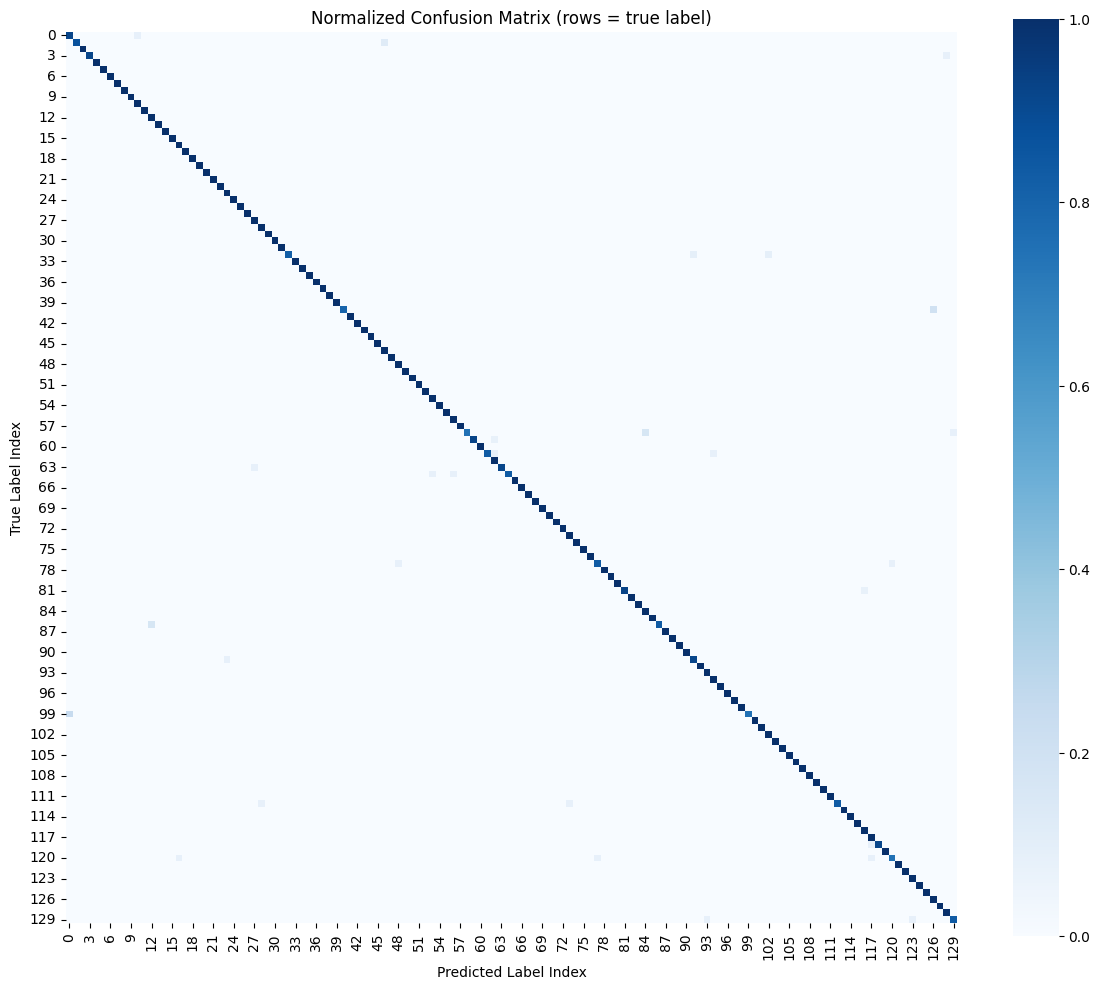

In [ ]:
# EVALUATION CELL 2 — Confusion Matrix (Normalized)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize row-wise
cm_norm = cm.astype(float) / (cm.sum(axis=1)[:, None] + 1e-9)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, cmap="Blues", square=True)
plt.title("Normalized Confusion Matrix (rows = true label)")
plt.xlabel("Predicted Label Index")
plt.ylabel("True Label Index")
plt.tight_layout()
plt.show()


Running t-SNE on 1500 samples... (this can take a minute)


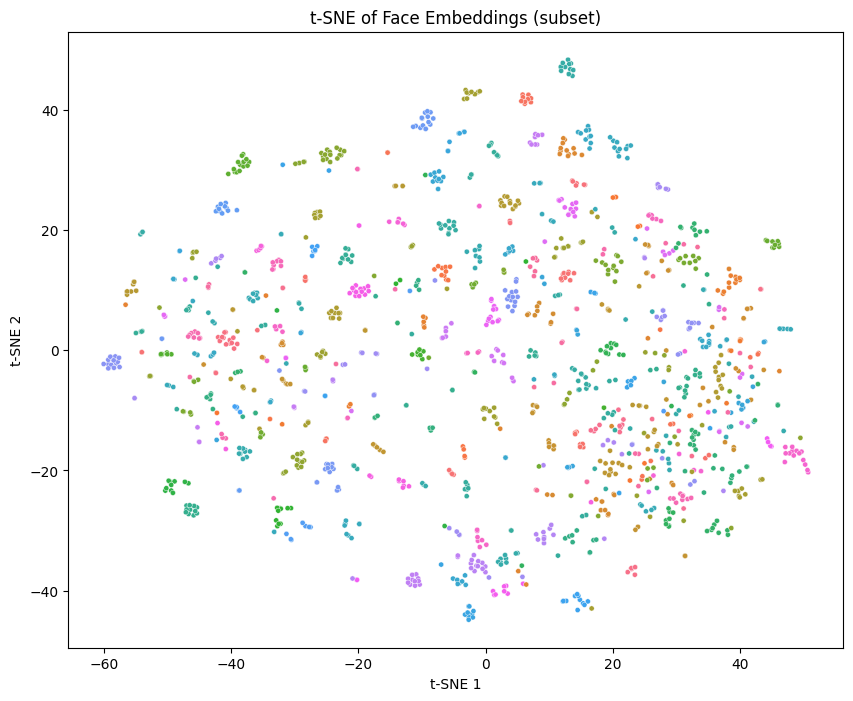

In [ ]:
# Evaluation Cell 3 — t-SNE visualization of embeddings (subset)
# If Xs/y are not present, this will load embeddings and recreate them.

import numpy as np
from pathlib import Path
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Helper: load & prepare data if needed
if 'Xs' not in globals() or 'y' not in globals() or 'le' not in globals():
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    EMB_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/embeddings")
    X = np.load(EMB_DIR / "embeddings.npy")
    y_labels = np.load(EMB_DIR / "labels.npy")
    le = LabelEncoder()
    y = le.fit_transform(y_labels)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    print("Loaded embeddings and prepared Xs, y, le.")

# choose subset for t-SNE (speed + clarity)
n_display = min(1500, Xs.shape[0])
rng = np.random.default_rng(42)
idx = rng.choice(Xs.shape[0], n_display, replace=False)
X_sub = Xs[idx]
y_sub = y[idx]

print("Running t-SNE on", X_sub.shape[0], "samples... (this can take a minute)")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X2 = tsne.fit_transform(X_sub)

plt.figure(figsize=(10,8))
sns.scatterplot(x=X2[:,0], y=X2[:,1],
                hue=[le.classes_[lab] for lab in y_sub],
                legend=False, s=14)
plt.title("t-SNE of Face Embeddings (subset)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


In [ ]:
# Evaluation Cell 4 — Save predictions CSV for analysis/report

import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed")

# Probabilities from model
pred_probs = clf_best.predict_proba(X_test)
pred_idx = pred_probs.argmax(axis=1)
pred_labels = le.inverse_transform(pred_idx)
true_labels = le.inverse_transform(y_test)

df = pd.DataFrame({
    "image_path": paths_test,
    "true_label": true_labels,
    "predicted_label": pred_labels,
    "prediction_confidence": pred_probs.max(axis=1)
})

csv_file = OUT_DIR / "svm_test_predictions.csv"
df.to_csv(csv_file, index=False)

print("Saved predictions to:", csv_file)
print("Total rows:", len(df))


Saved predictions to: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/svm_test_predictions.csv
Total rows: 1443


In [ ]:
# ================== INSTALL ==================
!pip install -q deepface==0.0.92 insightface==0.7.3 scikit-learn

# ================== INPUT =====================
# Change these paths to any two preprocessed images you want to verify
img1 = "/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject130/subject130_subject130.0_aligned.jpg"
img2 = "/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject13/subject13_subject13.0_aligned.jpg"
# img2 can also be from another subject to test negative case

# ================== CODE ======================
from deepface import DeepFace
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_embedding(path):
    rep = DeepFace.represent(
        img_path = path,
        model_name = "ArcFace",
        enforce_detection = False
    )
    if isinstance(rep, list):
        rep = rep[0]["embedding"]
    return np.array(rep, dtype=np.float32)

print("Extracting embeddings...")
emb1 = get_embedding(img1)
emb2 = get_embedding(img2)

print("\nEmbedding shapes:", emb1.shape, emb2.shape)

# ================== SIMILARITY ======================
sim = cosine_similarity([emb1], [emb2])[0][0]
print("\nCosine Similarity:", sim)

# ================== DECISION ======================
threshold = 0.35  # Typical ArcFace threshold (you can tune later)
result = "SAME PERSON" if sim >= threshold else "DIFFERENT PERSON"

print("\nVerification Result:", result)
print(f"(Decision threshold used = {threshold})")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.5/105.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 123.9 MB/s eta 0:00:00
26-01-28 12:00:51 - Directory /root/.deepface created
26-01-28 12:00:51 - Directory /root/.deepface/weights created
Extracting embeddings...
26-01-28 12:00:52 - arcface_weights.h5 will be downloaded to /root/.deepface/weights/arcface_weights.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:00<00:00, 295MB/s]



Embedding shapes: (512,) (512,)

Cosine Similarity: 0.96451294

Verification Result: SAME PERSON
(Decision threshold used = 0.35)


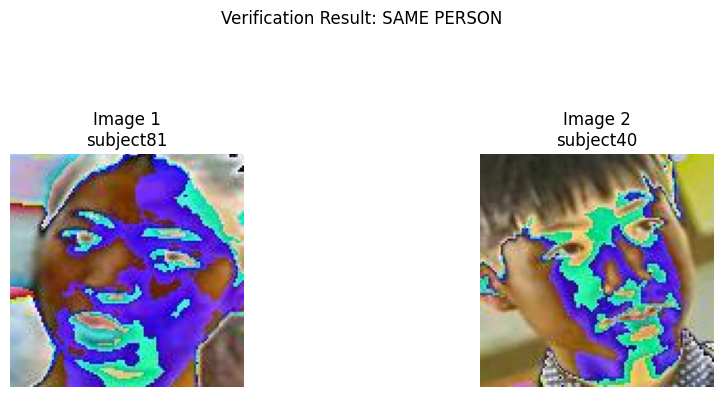

Image 1 Path: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject81/subject81_subject81.18_aligned.jpg
Image 2 Path: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject40/subject40_subject40.44_aligned.jpg
Cosine Similarity: 0.9623408
Verification Result: SAME PERSON


In [ ]:
# ================== RANDOM FACE VERIFICATION (SINGLE CELL) ==================

import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace
from sklearn.metrics.pairwise import cosine_similarity

# -------- DATASET ROOT --------
DATASET_ROOT = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")

# -------- RANDOM IMAGE SELECTION --------
all_images = list(DATASET_ROOT.rglob("*.jpg"))

if len(all_images) < 2:
    raise ValueError("Not enough images found")

img1, img2 = random.sample(all_images, 2)

# -------- EMBEDDING FUNCTION --------
def get_embedding(path):
    rep = DeepFace.represent(
        img_path=str(path),
        model_name="ArcFace",
        enforce_detection=False
    )
    if isinstance(rep, list):
        rep = rep[0]["embedding"]
    return np.array(rep, dtype=np.float32)

# -------- EXTRACT EMBEDDINGS --------
emb1 = get_embedding(img1)
emb2 = get_embedding(img2)

# -------- COSINE SIMILARITY --------
sim = cosine_similarity([emb1], [emb2])[0][0]
threshold = 0.35
result = "SAME PERSON" if sim >= threshold else "DIFFERENT PERSON"

# -------- DISPLAY IMAGES --------
img1_pil = Image.open(str(img1)).convert("RGB")
img2_pil = Image.open(str(img2)).convert("RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_pil)
plt.axis("off")
plt.title(f"Image 1\n{img1.parent.name}")

plt.subplot(1, 2, 2)
plt.imshow(img2_pil)
plt.axis("off")
plt.title(f"Image 2\n{img2.parent.name}")

plt.suptitle(
    f"Verification Result: {result}\n"
    ,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# -------- PRINT DETAILS --------
print("Image 1 Path:", img1)
print("Image 2 Path:", img2)
print("Cosine Similarity:", sim)
print("Verification Result:", result)


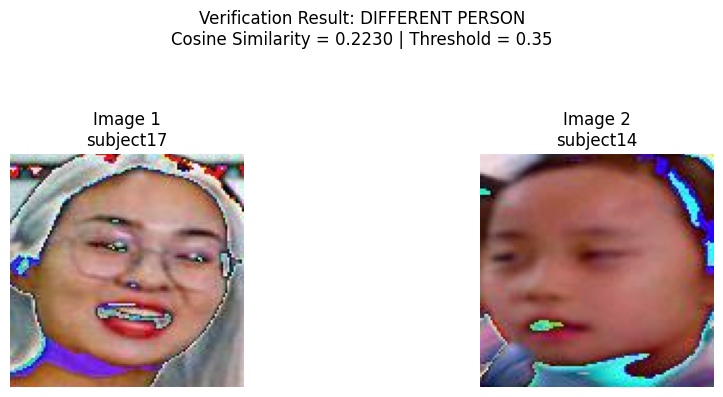

Image 1 Path: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject17/subject17_subject17.37_aligned.jpg
Image 2 Path: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject14/subject14_subject14.42_aligned.jpg
Cosine Similarity: 0.22299077
Verification Result: DIFFERENT PERSON


In [ ]:
# ================== RANDOM FACE VERIFICATION (SINGLE CELL) ==================

import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace
from sklearn.metrics.pairwise import cosine_similarity

# -------- DATASET ROOT --------
DATASET_ROOT = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")

# -------- RANDOM IMAGE SELECTION --------
all_images = list(DATASET_ROOT.rglob("*.jpg"))

if len(all_images) < 2:
    raise ValueError("Not enough images found")

img1, img2 = random.sample(all_images, 2)

# -------- EMBEDDING FUNCTION --------
def get_embedding(path):
    rep = DeepFace.represent(
        img_path=str(path),
        model_name="ArcFace",
        enforce_detection=False
    )
    if isinstance(rep, list):
        rep = rep[0]["embedding"]
    return np.array(rep, dtype=np.float32)

# -------- EXTRACT EMBEDDINGS --------
emb1 = get_embedding(img1)
emb2 = get_embedding(img2)

# -------- COSINE SIMILARITY --------
sim = cosine_similarity([emb1], [emb2])[0][0]
threshold = 0.35
result = "SAME PERSON" if sim >= threshold else "DIFFERENT PERSON"

# -------- DISPLAY IMAGES --------
img1_pil = Image.open(str(img1)).convert("RGB")
img2_pil = Image.open(str(img2)).convert("RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_pil)
plt.axis("off")
plt.title(f"Image 1\n{img1.parent.name}")

plt.subplot(1, 2, 2)
plt.imshow(img2_pil)
plt.axis("off")
plt.title(f"Image 2\n{img2.parent.name}")

plt.suptitle(
    f"Verification Result: {result}\n"
    f"Cosine Similarity = {sim:.4f} | Threshold = {threshold}",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# -------- PRINT DETAILS --------
print("Image 1 Path:", img1)
print("Image 2 Path:", img2)
print("Cosine Similarity:", sim)
print("Verification Result:", result)


In [ ]:
# ================== ARCFACE + FACENET512 SCORE FUSION (SINGLE CELL) ==================

import numpy as np
from deepface import DeepFace
from sklearn.metrics.pairwise import cosine_similarity

# -------- embedding extractor --------
def get_embedding(path, model):
    rep = DeepFace.represent(
        img_path=str(path),
        model_name=model,
        enforce_detection=False
    )
    if isinstance(rep, list):
        rep = rep[0]["embedding"]
    return np.array(rep, dtype=np.float32)

# -------- extract embeddings --------
emb_arc_1 = get_embedding(img1, "ArcFace")
emb_arc_2 = get_embedding(img2, "ArcFace")

emb_fn_1 = get_embedding(img1, "Facenet512")
emb_fn_2 = get_embedding(img2, "Facenet512")

# -------- cosine similarities --------
sim_arc = cosine_similarity([emb_arc_1], [emb_arc_2])[0][0]
sim_fn  = cosine_similarity([emb_fn_1],  [emb_fn_2])[0][0]

# -------- score fusion --------
alpha = 0.6   # ArcFace weight
beta  = 0.4   # Facenet512 weight

fused_sim = alpha * sim_arc + beta * sim_fn

# -------- decision --------
threshold = 0.35
result = "SAME PERSON" if fused_sim >= threshold else "DIFFERENT PERSON"

# -------- output --------
print("ArcFace Similarity   :", sim_arc)
print("Facenet512 Similarity:", sim_fn)
print("Fused Similarity     :", fused_sim)
print("Threshold            :", threshold)
print("Final Result         :", result)


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /root/.deepface/weights/facenet512_weights.h5


26-01-28 12:02:19 - facenet512_weights.h5 will be downloaded...


100%|██████████| 95.0M/95.0M [00:00<00:00, 255MB/s]


ArcFace Similarity   : 0.22299077
Facenet512 Similarity: 0.3108532
Fused Similarity     : 0.25813577
Threshold            : 0.35
Final Result         : DIFFERENT PERSON


In [ ]:
# ================== INSTALL + PICK IMAGES + SAVE ARCFACE MODEL ==================

# Install dependencies (safe if already installed)
!pip install -q deepface insightface scikit-learn

import pickle
import random
from pathlib import Path
import numpy as np
from deepface import DeepFace

# -------- DATASET ROOT (aligned images) --------
DATASET_ROOT = Path("/content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned")

all_images = list(DATASET_ROOT.rglob("*.jpg"))
if len(all_images) < 2:
    raise ValueError("Not enough images found in dataset")

# Pick two random images automatically
img1, img2 = random.sample(all_images, 2)

print("Selected Image 1:", img1)
print("Selected Image 2:", img2)

# -------- SAVE DIRECTORY --------
SAVE_DIR = Path("/content/drive/MyDrive/Face recognition/saved_model")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# -------- ArcFace embedding extractor --------
def get_arcface_embedding(path):
    rep = DeepFace.represent(
        img_path=str(path),
        model_name="ArcFace",
        enforce_detection=False
    )
    if isinstance(rep, list):
        rep = rep[0]["embedding"]
    return np.array(rep, dtype=np.float32)

# -------- Extract embeddings --------
emb_arc_1 = get_arcface_embedding(img1)
emb_arc_2 = get_arcface_embedding(img2)

# -------- Model configuration --------
model_config_arcface = {
    "model_used": "ArcFace (DeepFace)",
    "embedding_dim": emb_arc_1.shape[0],
    "threshold": 0.35,
    "similarity_metric": "cosine",
    "note": "Pre-trained ArcFace model. No training performed."
}

# -------- Reference embeddings --------
reference_embeddings_arcface = {
    "img1_path": str(img1),
    "img2_path": str(img2),
    "arcface_emb1": emb_arc_1,
    "arcface_emb2": emb_arc_2
}

# -------- Save artifacts --------
with open(SAVE_DIR / "arcface_model_config.pkl", "wb") as f:
    pickle.dump(model_config_arcface, f)

with open(SAVE_DIR / "arcface_reference_embeddings.pkl", "wb") as f:
    pickle.dump(reference_embeddings_arcface, f)

print("\n✅ ArcFace model artifacts saved successfully")
print("📁 Saved directory:", SAVE_DIR)


Selected Image 1: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject56/subject56_subject56.11_aligned.jpg
Selected Image 2: /content/drive/MyDrive/Face recognition/UCEC-Face-processed/aligned/subject3/subject3_subject3.11_aligned.jpg

✅ ArcFace model artifacts saved successfully
📁 Saved directory: /content/drive/MyDrive/Face recognition/saved_model
